# Notebook 2: Data Audit and Exploratory Data Analysis

## Objective

The purpose of this notebook is to understand the structure, quality, and risk-related patterns of the Home Credit application data before feature engineering or model development.

The analysis focuses on four questions:

1. **What information is available at the time of a lending decision?**
2. **How is loan default distributed across applicants?**
3. **Which data-quality issues could affect model development?**
4. **Which applicant characteristics appear associated with default risk?**

The goal of exploratory analysis is not simply to identify variables correlated with the target. It is also to identify:

- missing-data patterns,
- unusual or implausible values,
- categorical variables requiring encoding,
- highly skewed numerical variables,
- potential information leakage,
- and features that may require transformation or engineering.

Findings from this notebook will determine the preprocessing and feature-engineering decisions used in Notebook 3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import zipfile
import os
import getpass

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

## Lending Context

The prediction target is `TARGET`:

- `TARGET = 0`: the applicant did not experience the defined repayment difficulty.
- `TARGET = 1`: the applicant experienced repayment difficulty.

From a lending perspective, the model will eventually estimate

$$
P(Y = 1 \mid X),
$$

where $Y=1$ represents default or serious repayment difficulty and $X$ represents applicant information available when the credit decision is made.

At this stage, however, we are not building a predictive model. We first audit whether the available features are suitable inputs to such a model.

## Dataset Setup

This project uses the **Home Credit Default Risk** dataset originally released through a Kaggle competition.

The dataset contains information available about loan applicants as well as historical credit information from Home Credit and external credit bureaus.

The primary application-level datasets are:

- `application_train.csv`: labeled applications used for model development.
- `application_test.csv`: unlabeled applications originally used for Kaggle competition predictions.

Additional relational datasets contain historical information about applicants' previous loans, credit bureau records, credit cards, installment payments, and other credit activity.

Because the objective of this project is to build an end-to-end credit-risk decision system rather than simply reproduce a Kaggle submission, we will preserve these relational tables for later feature engineering.

In [2]:
%pip install -q kaggle


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
# KGAT_be559157dde009ab2355c1e80a1d4ee9
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("Enter your Kaggle API token: ")

Enter your Kaggle API token:  ········


In [4]:
%pip install -q --upgrade kaggle


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
!kaggle competitions list -s home-credit-default-risk

ref                                                                             deadline             category       reward  teamCount  userHasEntered  userRank  
------------------------------------------------------------------------------  -------------------  ---------  ----------  ---------  --------------  --------  
https://www.kaggle.com/competitions/home-credit-default-risk                    2018-08-29 23:59:00  Featured   70,000 Usd       7176            True         0  
https://www.kaggle.com/competitions/iiitb2020-home-credit-default-risk          2020-12-18 18:29:00  Community       Kudos         13           False         0  
https://www.kaggle.com/competitions/codeop-home-credit-default-risk             2020-06-21 23:59:00  Community       Kudos          5           False         0  
https://www.kaggle.com/competitions/da-pt-02                                    2021-01-31 23:59:00  Community       Kudos          4           False         0  
https://www.kaggle.com/compe

In [6]:
from pathlib import Path

DATA_DIR = Path("data")
RAW_DATA_DIR = DATA_DIR / "raw"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)

print(RAW_DATA_DIR.resolve())

/workspaces/kj-project-portfolio/Projects/credit-risk-decision-system/notebooks/data/raw


In [7]:
!kaggle competitions download \
    -c home-credit-default-risk \
    -p data/raw

home-credit-default-risk.zip: Skipping, found more recently modified local copy (use --force to force download)


In [8]:
!kaggle competitions files -c home-credit-default-risk

name                                      size  creationDate                
----------------------------------  ----------  --------------------------  
HomeCredit_columns_description.csv       37383  2019-12-11 02:55:39.025000  
POS_CASH_balance.csv                 392703158  2019-12-11 02:55:51.293000  
application_test.csv                  26567651  2019-12-11 02:55:45.469000  
application_train.csv                166133370  2019-12-11 02:55:46.979000  
bureau.csv                           170016717  2019-12-11 02:55:47.023000  
bureau_balance.csv                   375592889  2019-12-11 02:55:52.848000  
credit_card_balance.csv              424582605  2019-12-11 02:55:52.357000  
installments_payments.csv            723118349  2019-12-11 02:56:09.108000  
previous_application.csv             404973293  2019-12-11 02:55:55.841000  
sample_submission.csv                   536202  2019-12-11 02:55:48.980000  


In [9]:
for file in sorted(RAW_DATA_DIR.iterdir()):
    print(file.name)

.ipynb_checkpoints
HomeCredit_columns_description.csv
POS_CASH_balance.csv
application_test.csv
application_train.csv
bureau.csv
bureau_balance.csv
credit_card_balance.csv
home-credit-default-risk.zip
installments_payments.csv
previous_application.csv
sample_submission.csv


In [10]:
zip_path = RAW_DATA_DIR / "home-credit-default-risk.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(RAW_DATA_DIR)

print("Dataset extracted successfully.")

Dataset extracted successfully.


In [11]:
for file in sorted(RAW_DATA_DIR.iterdir()):
    print(file.name)

.ipynb_checkpoints
HomeCredit_columns_description.csv
POS_CASH_balance.csv
application_test.csv
application_train.csv
bureau.csv
bureau_balance.csv
credit_card_balance.csv
home-credit-default-risk.zip
installments_payments.csv
previous_application.csv
sample_submission.csv


In [12]:
train_path = RAW_DATA_DIR / "application_train.csv"
test_path = RAW_DATA_DIR / "application_test.csv"

application_train = pd.read_csv(train_path)
application_test = pd.read_csv(test_path)

In [13]:
print("Training data shape:", application_train.shape)
print("Test data shape:", application_test.shape)

Training data shape: (307511, 122)
Test data shape: (48744, 121)


In [14]:
print("Training columns:", application_train.shape[1])
print("Test columns:", application_test.shape[1])

train_only_columns = set(application_train.columns) - set(application_test.columns)
test_only_columns = set(application_test.columns) - set(application_train.columns)

print("\nColumns only in training data:")
print(train_only_columns)

print("\nColumns only in test data:")
print(test_only_columns)

Training columns: 122
Test columns: 121

Columns only in training data:
{'TARGET'}

Columns only in test data:
set()


In [15]:
application_train.dtypes.value_counts()

float64    65
int64      41
str        16
Name: count, dtype: int64

In [16]:
structural_summary = pd.DataFrame({
    "dtype": application_train.dtypes,
    "n_unique": application_train.nunique(dropna=False),
    "n_missing": application_train.isna().sum(),
    "missing_pct": application_train.isna().mean() * 100
})

structural_summary = structural_summary.sort_values(
    "missing_pct",
    ascending=False
)

structural_summary.head(20)

,dtype,n_unique,n_missing,missing_pct
COMMONAREA_AVG,float64,3182,214865,69.872297
COMMONAREA_MODE,float64,3129,214865,69.872297
COMMONAREA_MEDI,float64,3203,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,float64,215,213514,69.432963
NONLIVINGAPARTMENTS_MODE,float64,168,213514,69.432963
NONLIVINGAPARTMENTS_AVG,float64,387,213514,69.432963
FONDKAPREMONT_MODE,str,5,210295,68.386172
LIVINGAPARTMENTS_AVG,float64,1869,210199,68.354953
LIVINGAPARTMENTS_MEDI,float64,1098,210199,68.354953
LIVINGAPARTMENTS_MODE,float64,737,210199,68.354953


In [17]:
print(
    "Number of duplicated rows:",
    application_train.duplicated().sum()
)

print(
    "Number of duplicated applicant IDs:",
    application_train["SK_ID_CURR"].duplicated().sum()
)

Number of duplicated rows: 0
Number of duplicated applicant IDs: 0


### Applicant Identifier

`SK_ID_CURR` identifies an application/customer record.

The identifier itself should generally not be treated as a predictive feature because its numeric magnitude has no meaningful relationship with creditworthiness.

However, it is important during the data audit because it allows us to verify whether the primary application table contains duplicate applicant records and will later provide the key for joining information from the auxiliary Home Credit tables.

### Structural Audit Findings

The application-level training data contains 307,511 observations and 122 columns, while the test data contains 48,744 observations and 121 columns. `TARGET` is the only feature present exclusively in the training set, confirming that the train and test schemas are otherwise aligned.

The dataset contains a mixture of numerical and categorical variables, including 65 floating-point columns, 41 integer columns, and 16 string-valued categorical columns. This indicates that later preprocessing will require type-specific treatment.

Missingness is substantial for several variables. Some housing and property-related features are missing for more than 60% of applicants. These variables should not be discarded solely based on missingness, because missing information may itself contain predictive information in a credit-risk setting.

No fully duplicated rows or duplicated `SK_ID_CURR` values were found. Therefore, the application table can be treated as containing one unique record per application.

## Target Distribution and Class Imbalance

The target variable identifies whether an applicant experienced serious repayment difficulty.

Before modeling, we examine the prevalence of the positive class because credit-default datasets are often imbalanced. Class imbalance affects:

- the usefulness of accuracy as an evaluation metric,
- classification thresholds,
- model training,
- and the business interpretation of prediction errors.

In [18]:
application_train["TARGET"].value_counts(dropna=False)

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [19]:
target_counts = application_train["TARGET"].value_counts().sort_index()
target_rates = application_train["TARGET"].value_counts(
    normalize=True
).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "proportion": target_rates,
    "percentage": target_rates * 100
})

target_summary

,count,proportion,percentage
TARGET,,,
0,282686,0.919271,91.927118
1,24825,0.080729,8.072882


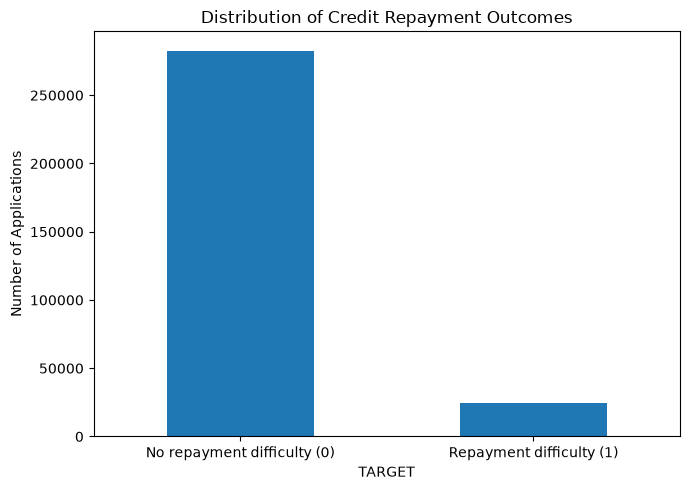

In [20]:
ax = target_counts.plot(kind="bar", figsize=(7, 5))

ax.set_title("Distribution of Credit Repayment Outcomes")
ax.set_xlabel("TARGET")
ax.set_ylabel("Number of Applications")
ax.set_xticklabels(
    ["No repayment difficulty (0)", "Repayment difficulty (1)"],
    rotation=0
)

plt.tight_layout()
plt.show()

In [21]:
non_default_count = target_counts.loc[0]
default_count = target_counts.loc[1]

imbalance_ratio = non_default_count / default_count

print(
    f"Approximately {imbalance_ratio:.2f} non-default observations "
    "exist for every default observation."
)

Approximately 11.39 non-default observations exist for every default observation.


In [22]:
majority_class_accuracy = target_rates.max()

print(
    f"Majority-class baseline accuracy: "
    f"{majority_class_accuracy:.4f} "
    f"({majority_class_accuracy * 100:.2f}%)"
)

Majority-class baseline accuracy: 0.9193 (91.93%)


### Target Distribution Findings

The target is strongly imbalanced.

Approximately 91.93% of applicants are labeled `TARGET = 0`, while only 8.07% are labeled `TARGET = 1`. This corresponds to roughly 11.39 non-default observations for every default observation.

A naive classifier that predicts the majority class for every applicant would already achieve approximately 91.93% accuracy. Therefore, accuracy alone would provide a misleading assessment of model quality.

For this project, model evaluation should instead emphasize metrics that measure the model's ability to distinguish high-risk applicants, including ROC-AUC, precision, recall, and precision-recall performance. The eventual classification threshold should also be chosen with lending costs in mind, since failing to identify a risky borrower and incorrectly rejecting a reliable borrower have different business consequences.

## Missing-Value Audit

Missing information is common in credit application data and can arise because a characteristic is unavailable, not applicable, not reported, or not collected for a particular applicant.

We therefore examine missingness at both the feature level and the applicant level.

The objective is not to immediately remove incomplete variables. Instead, we first determine:

- how widespread missingness is,
- which features are most affected,
- whether groups of variables share similar missingness patterns,
- and whether missingness itself may contain information about repayment risk.

In [23]:
feature_missing = pd.DataFrame({
    "n_missing": application_train.isna().sum(),
    "missing_pct": application_train.isna().mean() * 100
})

feature_missing = feature_missing.sort_values(
    "missing_pct",
    ascending=False
)

print(
    "Features containing at least one missing value:",
    (feature_missing["n_missing"] > 0).sum()
)

print(
    "Features with no missing values:",
    (feature_missing["n_missing"] == 0).sum()
)

print(
    "Features with > 50% missing values:",
    (feature_missing["missing_pct"] > 50).sum()
)

print(
    "Features with > 30% missing values:",
    (feature_missing["missing_pct"] > 30).sum()
)

Features containing at least one missing value: 67
Features with no missing values: 55
Features with > 50% missing values: 41
Features with > 30% missing values: 50
